# 01 - Burgers' Equation Experiments
**AC-PINN Project** | Authors: Suyash Vasal Jain, Nishita Raghvendra

**PDE:** $u_t + u u_x = \nu u_{xx}$, $\nu = 0.01/\pi$

**IC:** $u(x,0) = -\sin(\pi x)$ | **BC:** $u(-1,t) = u(1,t) = 0$

**Domain:** $x \in [-1,1]$, $t \in [0,1]$

**Architecture:** `[2, 64, 64, 64, 64, 64, 1]` | **Epochs:** 10000

---
### Experiments
1. Vanilla PINN - clean dense data
2. Vanilla PINN - noisy sparse data (ε=0.1, N_ic=20)
3. AC-PINN - clean dense data
4. AC-PINN - noisy sparse data (ε=0.1, N_ic=20)

In [1]:
import sys, os
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinn_base import (
    device, NoisyDataGenerator, PINNSolver, ACPINNSolver,
    BurgersFDM, Benchmark, save_metrics, save_history
)

PDE      = 'burgers'
LAYERS   = [2, 64, 64, 64, 64, 64, 1]
EPOCHS   = 10000
PDE_PARAMS = {'nu': 0.01/np.pi}
RESULTS  = '../results/burgers/'
FIGURES  = '../figures/burgers/'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

gen = NoisyDataGenerator(pde=PDE, **PDE_PARAMS)
print(f'Device: {device}')

Device: cuda


## Section 1 - FDM Ground Truth

BurgersFDM solved in 0.7182s


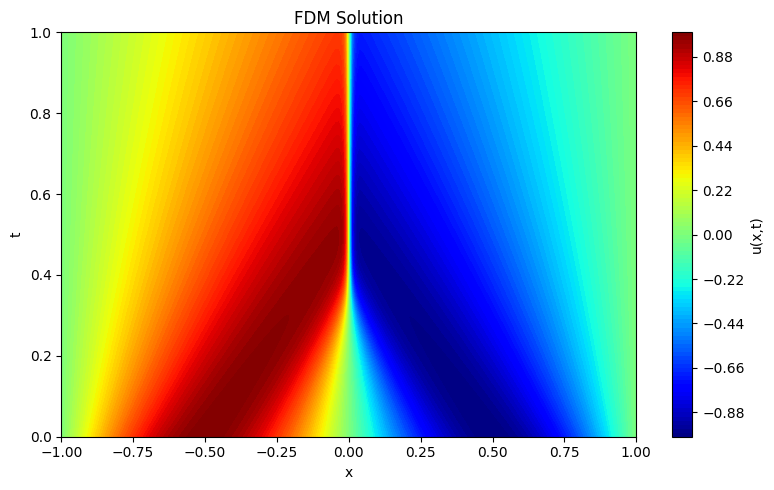

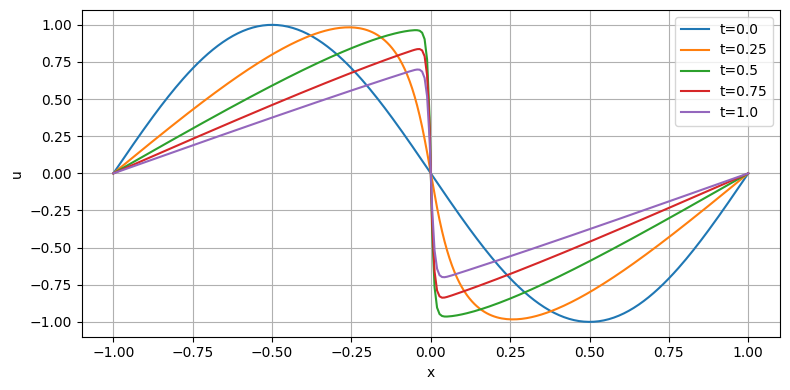

FDM runtime: 0.7182s


In [2]:
fdm = BurgersFDM(nx=256, nt=2000, nu=0.01/np.pi)
fdm.solve()
fdm.plot_solution()
fdm.plot_time_slices()
print(f'FDM runtime: {fdm.runtime:.4f}s')

## Section 2 - Data Conditions

In [3]:
# Clean dense
data_clean_dense  = gen.generate(N_ic=1000, N_bc=1000, N_f=8000, noise_eps=0.0)
# Noisy sparse
data_noisy_sparse = gen.generate(N_ic=20,   N_bc=20,   N_f=2000, noise_eps=0.1)

print('Data conditions ready')
print(f'  Clean dense  : N_ic={data_clean_dense["x_ic"].shape[0]}')
print(f'  Noisy sparse : N_ic={data_noisy_sparse["x_ic"].shape[0]}, eps=0.1')

Data conditions ready
  Clean dense  : N_ic=1000
  Noisy sparse : N_ic=20, eps=0.1


## Section 3 - Experiment 1: Vanilla PINN, Clean Dense

D:\PINN\ac-pinn-project\ac-pinn-project\venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch     0 | Total: 1.822263 | IC: 0.650241 | BC: 0.201934 | PDE: 0.194018


Epoch  1000 | Total: 0.114720 | IC: 0.096304 | BC: 0.001033 | PDE: 0.003477


Epoch  2000 | Total: 0.081584 | IC: 0.071530 | BC: 0.000218 | PDE: 0.001967


Epoch  3000 | Total: 0.051668 | IC: 0.041127 | BC: 0.000090 | PDE: 0.002090


...

Epoch  6000 | Total: 0.003977 | IC: 0.002649 | BC: 0.000005 | PDE: 0.000265


Epoch  7000 | Total: 0.002977 | IC: 0.001913 | BC: 0.000004 | PDE: 0.000212


Epoch  8000 | Total: 0.002276 | IC: 0.001458 | BC: 0.000003 | PDE: 0.000163


Epoch  9000 | Total: 0.001843 | IC: 0.001093 | BC: 0.000002 | PDE: 0.000150



Training complete in 143.15s


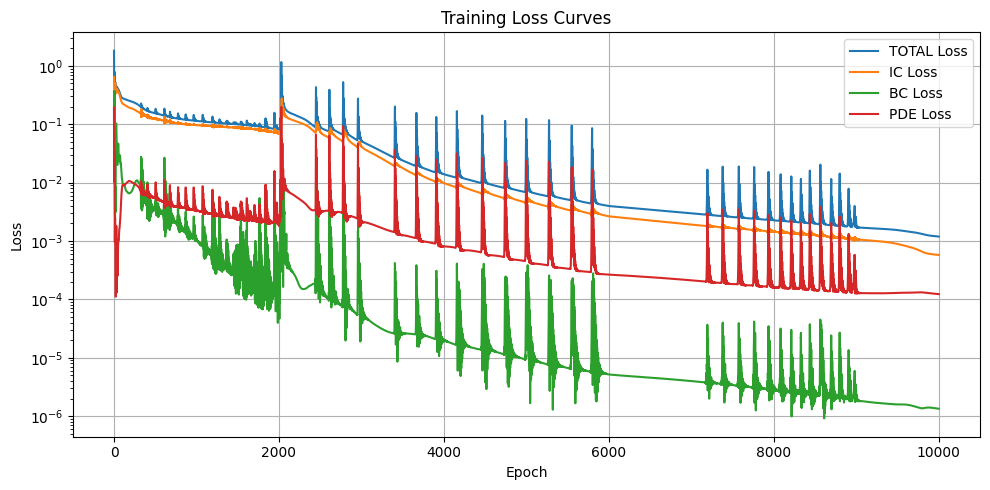

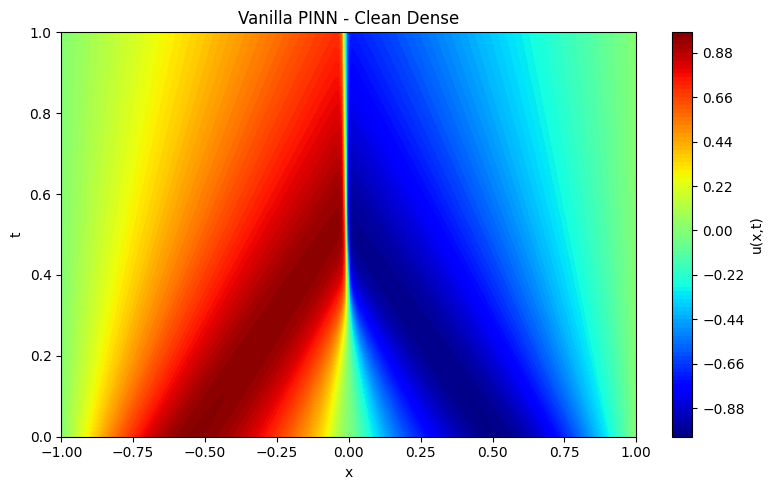

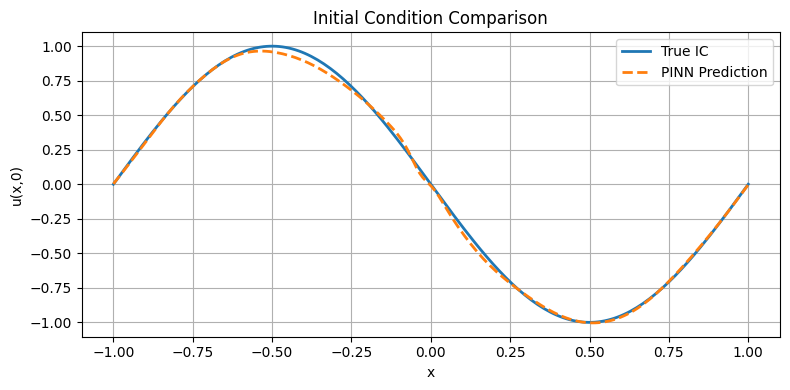

Saved: ../results/burgers/vanilla_clean_history.npy


In [4]:
vanilla_clean = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                            lambda_ic=1.0, lambda_bc=1.0, lambda_pde=5.0)
h_vc = vanilla_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Burgers | Vanilla Clean')
vanilla_clean.plot_loss_history(h_vc)
vanilla_clean.plot_solution(title='Vanilla PINN - Clean Dense')
vanilla_clean.plot_initial_condition_comparison(gen)
save_history(h_vc, RESULTS + 'vanilla_clean_history.npy')

## Section 4 - Experiment 2: Vanilla PINN, Noisy Sparse

Epoch     0 | Total: 0.624307 | IC: 0.440284 | BC: 0.042034 | PDE: 0.028398


Epoch  1000 | Total: 0.086531 | IC: 0.057496 | BC: 0.012263 | PDE: 0.003354


Epoch  2000 | Total: 0.047787 | IC: 0.027154 | BC: 0.012230 | PDE: 0.001680


Epoch  3000 | Total: 0.027949 | IC: 0.011543 | BC: 0.012170 | PDE: 0.000847


Epoch  4000 | Total: 0.028760 | IC: 0.007519 | BC: 0.012327 | PDE: 0.001783


...

Epoch  6000 | Total: 0.022032 | IC: 0.004248 | BC: 0.011974 | PDE: 0.001162


Epoch  7000 | Total: 0.016509 | IC: 0.003568 | BC: 0.011639 | PDE: 0.000261


Epoch  8000 | Total: 0.015680 | IC: 0.003090 | BC: 0.011492 | PDE: 0.000220


Epoch  9000 | Total: 0.015054 | IC: 0.002758 | BC: 0.011360 | PDE: 0.000187



Training complete in 127.60s


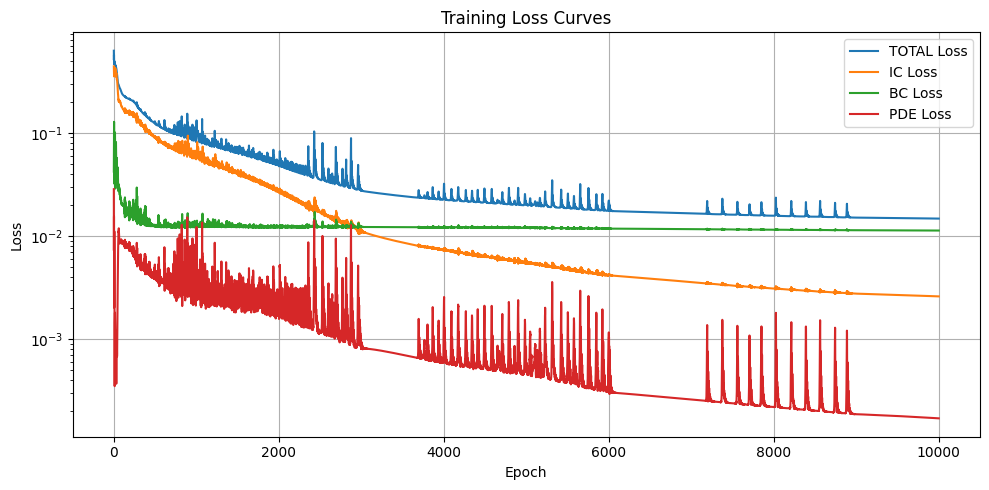

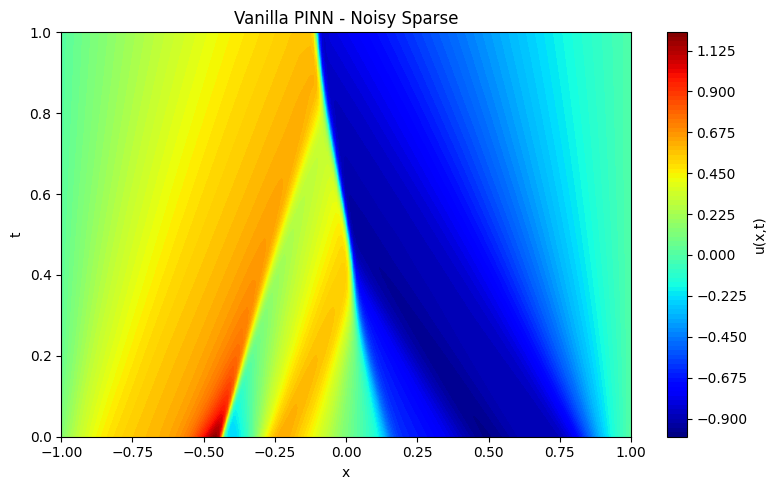

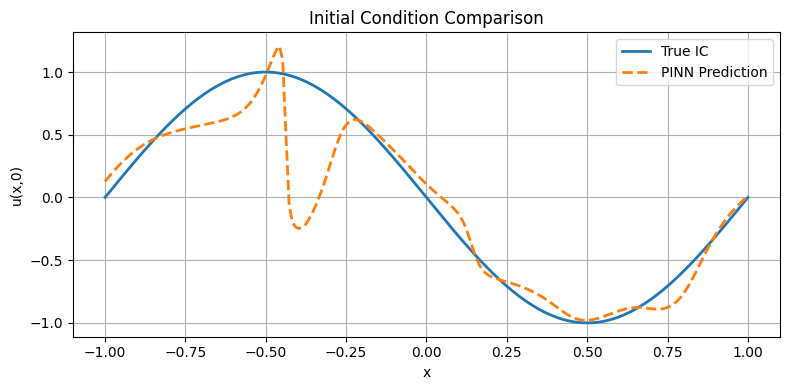

Saved: ../results/burgers/vanilla_noisy_history.npy


In [5]:
vanilla_noisy = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                            lambda_ic=1.0, lambda_bc=1.0, lambda_pde=5.0)
h_vn = vanilla_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Burgers | Vanilla Noisy')
vanilla_noisy.plot_loss_history(h_vn)
vanilla_noisy.plot_solution(title='Vanilla PINN - Noisy Sparse')
vanilla_noisy.plot_initial_condition_comparison(gen)
save_history(h_vn, RESULTS + 'vanilla_noisy_history.npy')

## Section 5 - Experiment 3: AC-PINN, Clean Dense

Epoch     0 | Stage 1/4 | Total: 0.710202 | IC: 0.524228 | BC: 0.026399 | PDE: 0.031915 | λ=(1.00,1.00,5.00)


Epoch  1000 | Stage 1/4 | Total: 0.011040 | IC: 0.004418 | BC: 0.000152 | PDE: 0.000452 | λ=(1.23,10.00,9.03)


Epoch  2000 | Stage 1/4 | Total: 0.001263 | IC: 0.000028 | BC: 0.000077 | PDE: 0.000237 | λ=(10.00,1.42,3.67)


Epoch  3000 | Stage 2/4 | Total: 0.000932 | IC: 0.000026 | BC: 0.000012 | PDE: 0.000270 | λ=(10.00,1.84,2.40)


Epoch  4000 | Stage 2/4 | Total: 0.000770 | IC: 0.000032 | BC: 0.000017 | PDE: 0.000067 | λ=(1.87,2.56,10.00)


...

Epoch  6000 | Stage 3/4 | Total: 0.002130 | IC: 0.000499 | BC: 0.000456 | PDE: 0.000944 | λ=(0.79,0.72,1.49)


Epoch  7000 | Stage 3/4 | Total: 0.001623 | IC: 0.000432 | BC: 0.000030 | PDE: 0.000639 | λ=(1.18,0.10,1.74)


Epoch  8000 | Stage 4/4 | Total: 0.304574 | IC: 0.108296 | BC: 0.003188 | PDE: 0.004342 | λ=(2.80,0.10,0.11)


Epoch  9000 | Stage 4/4 | Total: 0.613842 | IC: 0.000802 | BC: 0.000809 | PDE: 0.206159 | λ=(0.10,0.10,2.98)



AC-PINN training complete in 170.48s


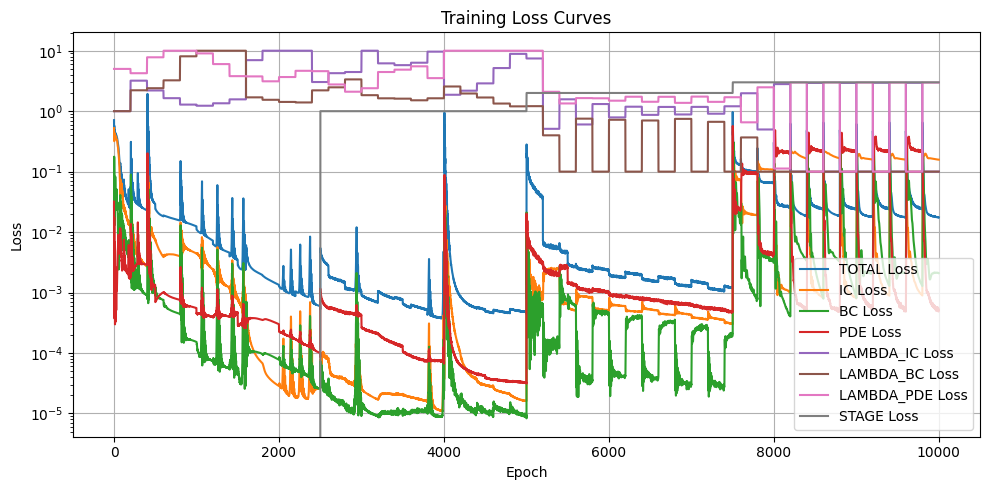

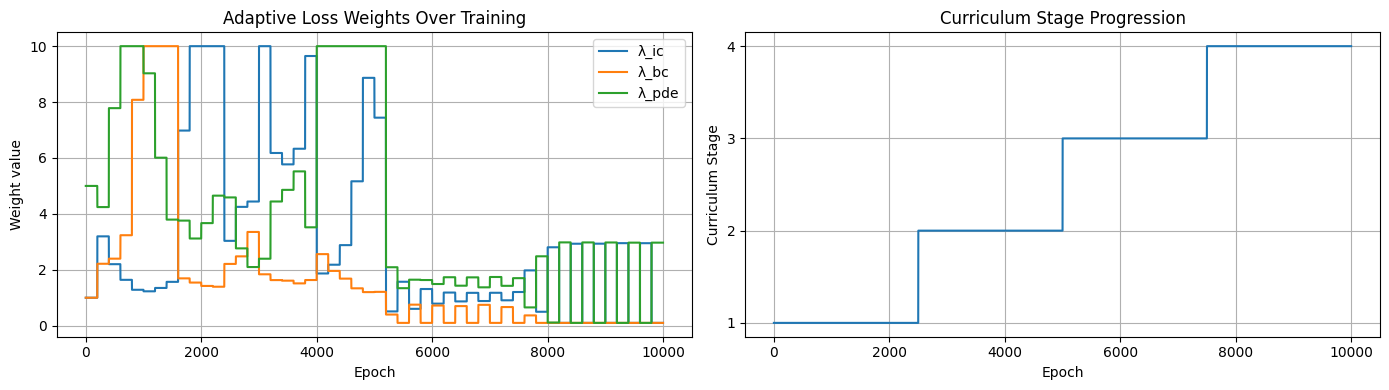

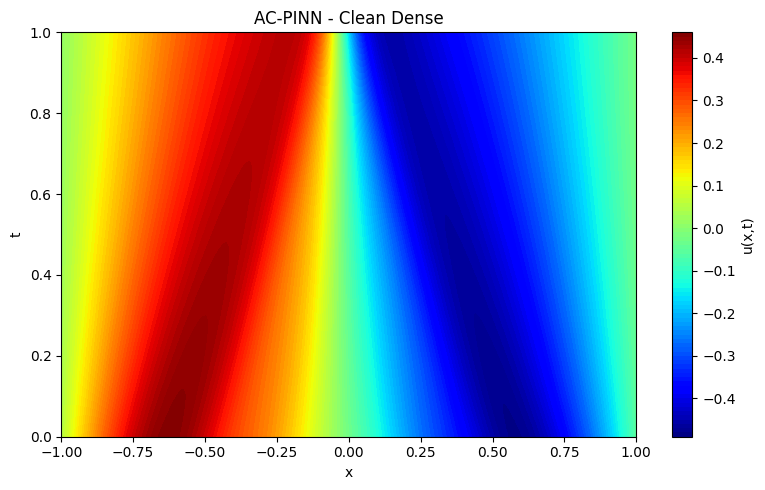

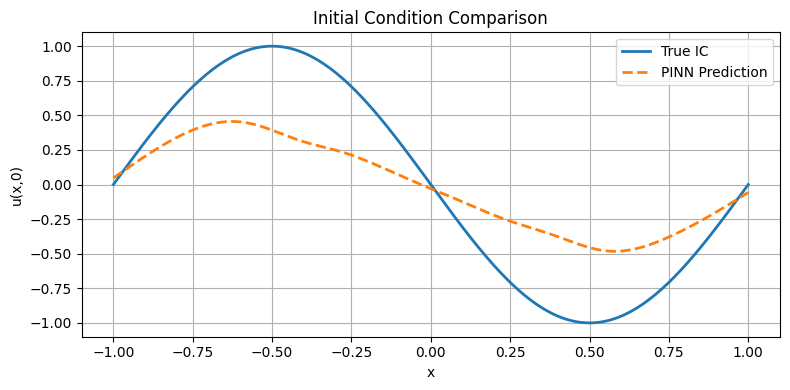

Saved: ../results/burgers/ac_clean_history.npy


In [6]:
ac_clean = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                         weight_strategy='both', N_pool=20000, resample_every=500)
h_ac = ac_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Burgers | AC-PINN Clean')
ac_clean.plot_loss_history(h_ac)
ac_clean.plot_weight_history(h_ac)
ac_clean.plot_solution(title='AC-PINN - Clean Dense')
ac_clean.plot_initial_condition_comparison(gen)
save_history(h_ac, RESULTS + 'ac_clean_history.npy')

## Section 6 - Experiment 4: AC-PINN, Noisy Sparse

Epoch     0 | Stage 1/4 | Total: 1.532405 | IC: 0.332215 | BC: 0.432477 | PDE: 0.153543 | λ=(1.00,1.00,5.00)


Epoch  1000 | Stage 1/4 | Total: 0.049080 | IC: 0.007097 | BC: 0.008878 | PDE: 0.000043 | λ=(2.38,3.61,3.30)


Epoch  2000 | Stage 1/4 | Total: 0.027232 | IC: 0.004812 | BC: 0.008411 | PDE: 0.000014 | λ=(2.21,1.96,10.00)


Epoch  3000 | Stage 2/4 | Total: 0.033317 | IC: 0.003758 | BC: 0.007489 | PDE: 0.000284 | λ=(1.79,3.27,7.43)


Epoch  4000 | Stage 2/4 | Total: 0.026118 | IC: 0.003450 | BC: 0.006639 | PDE: 0.000074 | λ=(2.15,2.75,5.85)


...

Epoch  6000 | Stage 3/4 | Total: 0.013650 | IC: 0.003242 | BC: 0.006094 | PDE: 0.002354 | λ=(0.83,1.56,0.60)


Epoch  7000 | Stage 3/4 | Total: 0.013021 | IC: 0.003092 | BC: 0.005793 | PDE: 0.001778 | λ=(0.87,1.63,0.50)


Epoch  8000 | Stage 4/4 | Total: 0.197710 | IC: 0.031964 | BC: 0.012548 | PDE: 0.086245 | λ=(0.73,0.29,1.98)


Epoch  9000 | Stage 4/4 | Total: 0.463277 | IC: 0.166103 | BC: 0.012975 | PDE: 0.000702 | λ=(2.77,0.22,0.10)



AC-PINN training complete in 145.75s


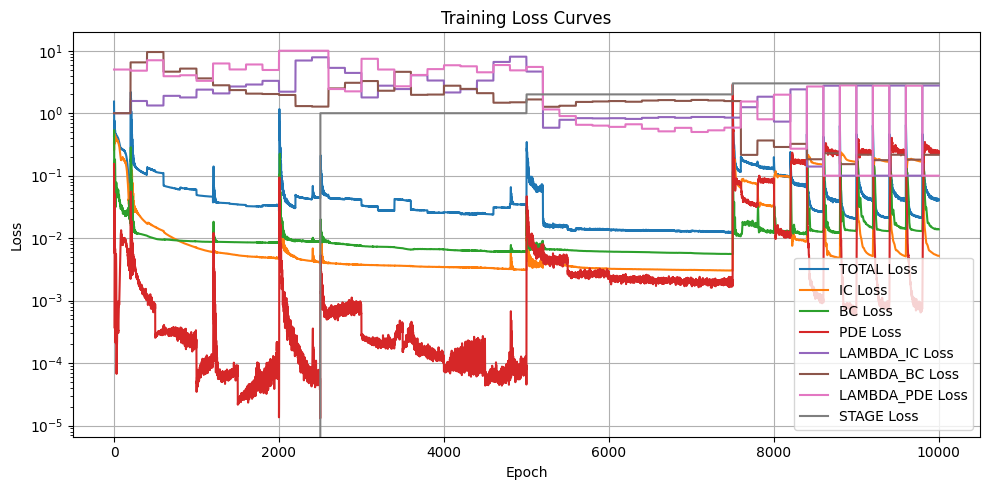

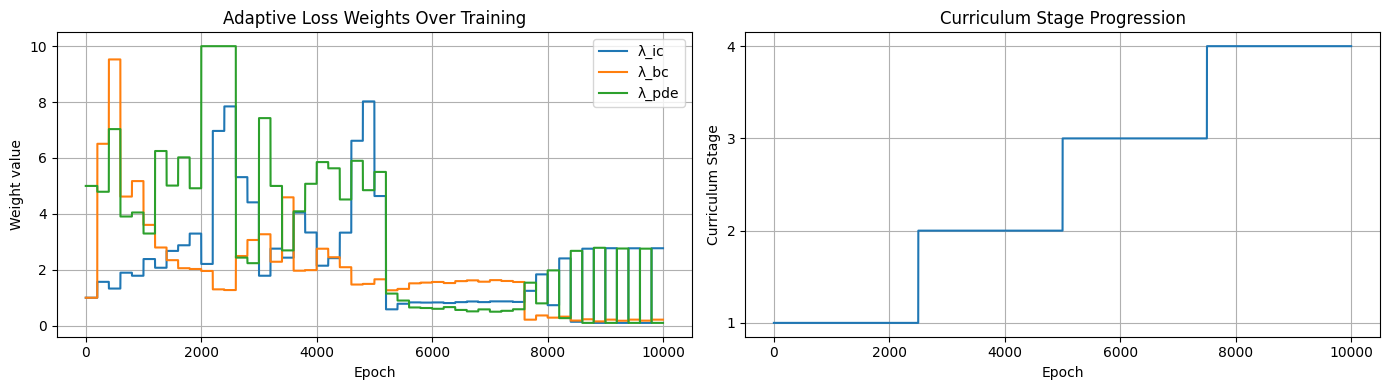

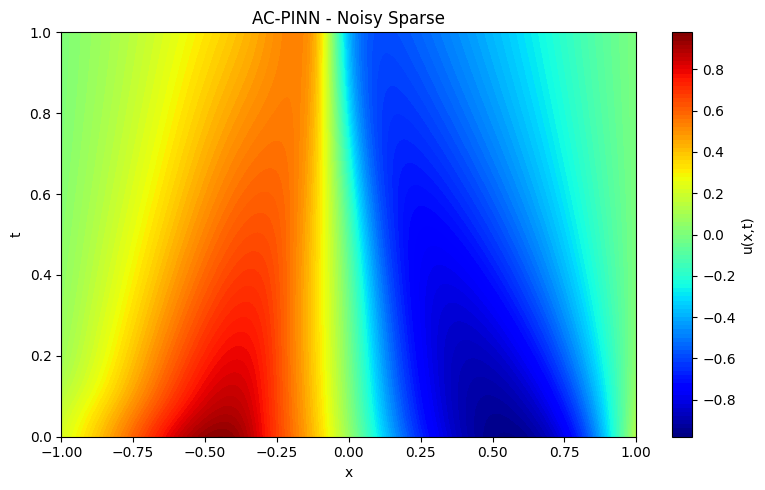

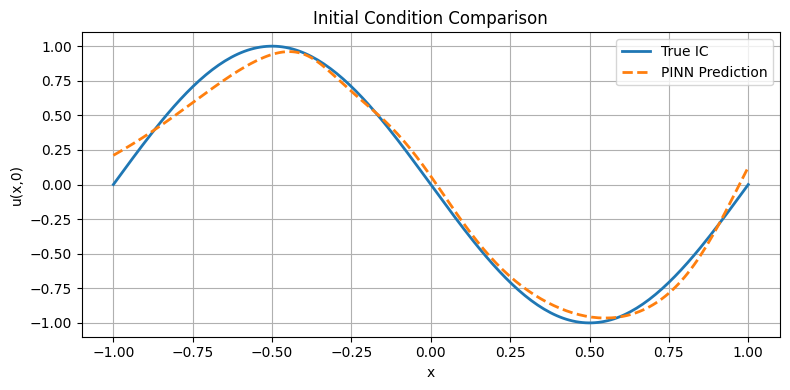

Saved: ../results/burgers/ac_noisy_history.npy


In [7]:
ac_noisy = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                         weight_strategy='both', N_pool=20000, resample_every=500)
h_an = ac_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Burgers | AC-PINN Noisy')
ac_noisy.plot_loss_history(h_an)
ac_noisy.plot_weight_history(h_an)
ac_noisy.plot_solution(title='AC-PINN - Noisy Sparse')
ac_noisy.plot_initial_condition_comparison(gen)
save_history(h_an, RESULTS + 'ac_noisy_history.npy')

## Section 7 - Benchmark vs FDM

  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla (clean)             0.115412   1.139691   0.014179   0.070190
  Vanilla (noisy)             0.440557   1.724121   0.121482   0.267931
  AC-PINN (clean)             0.589645   0.957813   0.263010   0.358601
  AC-PINN (noisy)             0.333683   0.935486   0.116354   0.202934


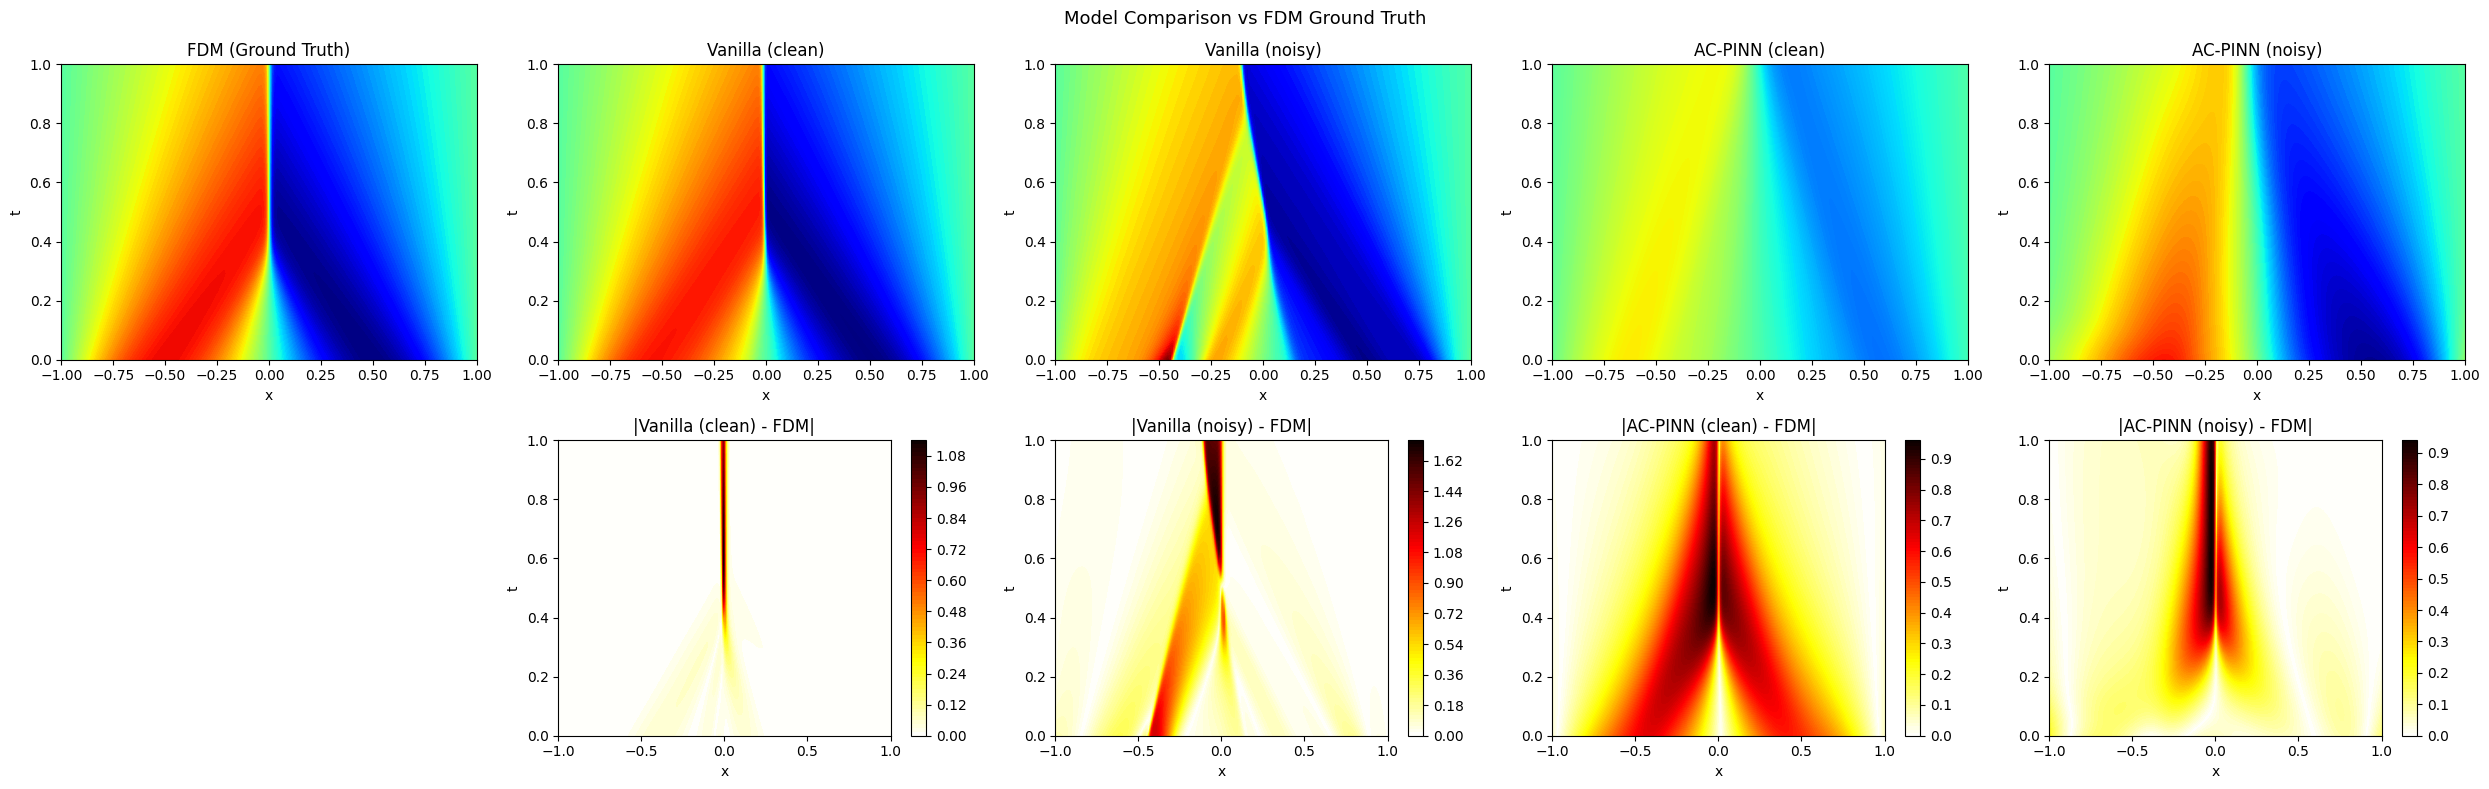

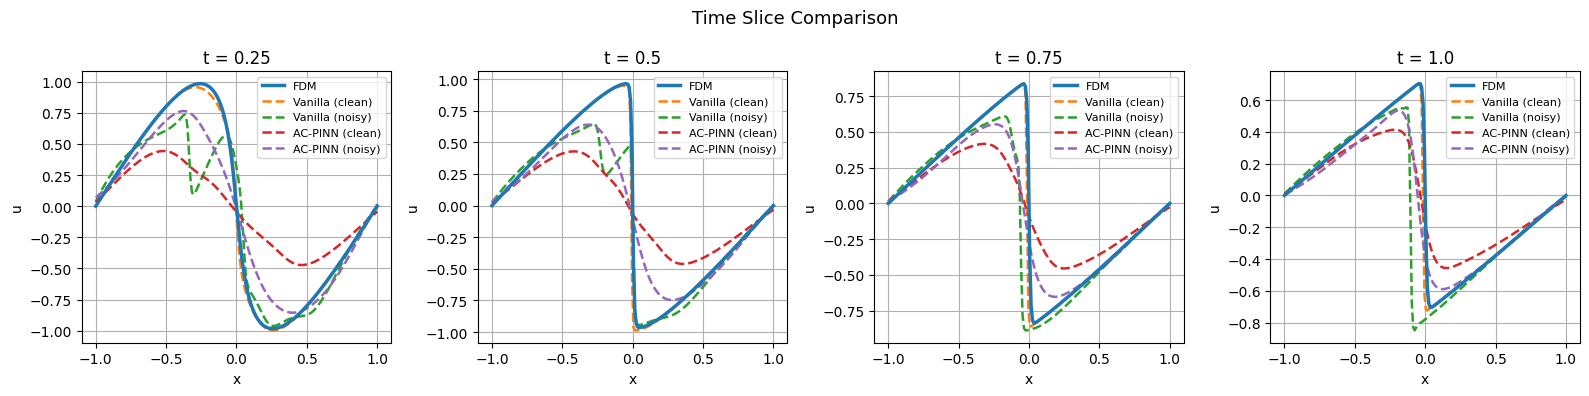

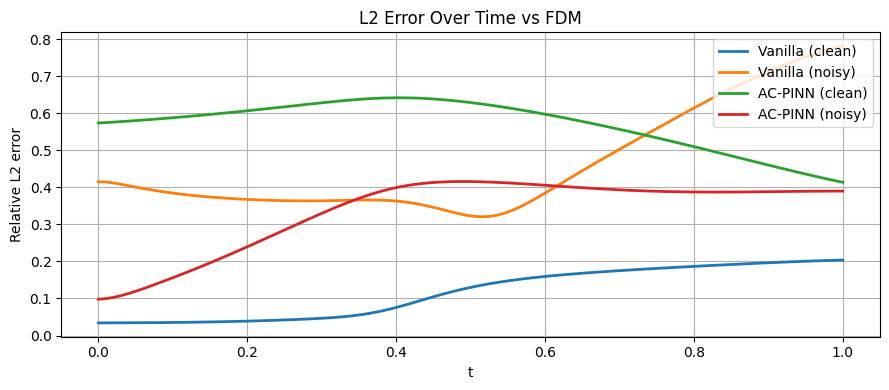

Saved: ../results/burgers/benchmark_metrics.npy
Burgers experiments complete. Results saved.


In [8]:
bench = Benchmark(fdm, nx=200, nt=100)
bench.add('Vanilla (clean)',  vanilla_clean)
bench.add('Vanilla (noisy)',  vanilla_noisy)
bench.add('AC-PINN (clean)',  ac_clean)
bench.add('AC-PINN (noisy)',  ac_noisy)
bench.run()

metrics = bench.compare_metrics()
bench.plot_comparison(save_path=FIGURES+'comparison.png')
bench.plot_time_slices(save_path=FIGURES+'time_slices.png')
bench.plot_error_over_time(save_path=FIGURES+'error_over_time.png')

save_metrics(metrics, RESULTS+'benchmark_metrics.npy')
print('Burgers experiments complete. Results saved.')

## Section 8 - Noise Level Study (ε = 0.05, 0.1, 0.2)
AC-PINN vs Vanilla under increasing noise.

In [9]:
noise_results = {}
for eps in [0.05, 0.1, 0.2]:
    print(f'\n--- Noise level ε={eps} ---')
    d = gen.generate(N_ic=50, N_bc=50, N_f=3000, noise_eps=eps)

    v = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
    v.fit(d, epochs=5000, print_every=2500)

    a = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
    a.fit(d, epochs=5000, print_every=2500)

    b = Benchmark(fdm).add(f'Vanilla ε={eps}', v).add(f'AC-PINN ε={eps}', a)
    b.run()
    noise_results[eps] = b.compare_metrics()

save_metrics(noise_results, RESULTS+'noise_study_metrics.npy')
print('Noise study complete.')


--- Noise level ε=0.05 ---
Epoch     0 | Total: 0.750961 | IC: 0.443755 | BC: 0.072566 | PDE: 0.046928


Epoch  2500 | Total: 0.068973 | IC: 0.051134 | BC: 0.006297 | PDE: 0.002308



Training complete in 64.50s
Epoch     0 | Stage 1/4 | Total: 0.389140 | IC: 0.249167 | BC: 0.128435 | PDE: 0.002308 | λ=(1.00,1.00,5.00)


Epoch  2500 | Stage 2/4 | Total: 0.036332 | IC: 0.002592 | BC: 0.005982 | PDE: 0.000375 | λ=(10.00,1.54,3.13)



AC-PINN training complete in 69.37s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.05              0.279099   1.659060   0.062678   0.169738
  AC-PINN ε=0.05              0.312642   0.804163   0.106549   0.190138

--- Noise level ε=0.1 ---
Epoch     0 | Total: 0.578411 | IC: 0.546482 | BC: 0.028803 | PDE: 0.000625


...


AC-PINN training complete in 73.20s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.1               0.672556   1.966749   0.160826   0.409025
  AC-PINN ε=0.1               0.333997   0.920509   0.113479   0.203125

--- Noise level ε=0.2 ---
Epoch     0 | Total: 0.585797 | IC: 0.510803 | BC: 0.070866 | PDE: 0.000826


Epoch  2500 | Total: 0.130061 | IC: 0.055442 | BC: 0.068153 | PDE: 0.001293



Training complete in 66.73s
Epoch     0 | Stage 1/4 | Total: 0.843613 | IC: 0.676063 | BC: 0.167509 | PDE: 0.000008 | λ=(1.00,1.00,5.00)


Epoch  2500 | Stage 2/4 | Total: 0.188333 | IC: 0.035991 | BC: 0.045698 | PDE: 0.000317 | λ=(2.60,2.01,8.40)



AC-PINN training complete in 73.67s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.2               0.699000   1.991296   0.187667   0.425107
  AC-PINN ε=0.2               0.351601   0.898423   0.127916   0.213831
Saved: ../results/burgers/noise_study_metrics.npy
Noise study complete.
